# Notebook 06 (Exp 2) — BLEU + BERTScore Evaluation

Evaluates exp2 models on the held-out test set. **Primary contribution: introduces BERTScore metric** for style transfer evaluation (BLEU inadequate for paraphrase-heavy tasks).

**Exp 2 improvements over Exp 1:**
- Early stopping for LoRA (overfitting fix)
- Higher LR for FFT (underfitting fix)
- Adds **BERTScore** (F1, precision, recall) — semantic similarity metric more appropriate for style transfer than BLEU
  - Uses `distilbert-base-uncased` (fast iteration; Exp 3 upgrades to `roberta-large`)
- Bidirectional training data (Mod↔Shak) — later found to be suboptimal
- Saves scores to `outputs/exp2/results/bleu_scores.json`

**Expected results:** BERTScore F1 ≈ 0.68–0.70 (development baseline; Exp 3 will breach 0.84 with unidirectional training)

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Blackwell (sm_120): enable expandable segments to reduce memory fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import AutoPeftModelForCausalLM

sys.path.insert(0, str(Path('..').resolve()))
from src.evaluation import compute_bleu_scores, compute_bert_scores, run_batch_inference

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
LORA_PATH     = ROOT / 'outputs' / 'exp2' / 'lora'  / 'final_adapter'
FFT_PATH      = ROOT / 'outputs' / 'exp2' / 'fft'   / 'final_model'
RESULTS_DIR   = ROOT / 'outputs' / 'exp2' / 'results'
FIG_DIR       = ROOT / 'outputs' / 'exp2' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_JSONL = PROCESSED_DIR / 'test.jsonl'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
print('Setup complete.')


Setup complete.


## 1. Load LoRA Model and Run Inference

In [2]:
print('Loading Exp 2 LoRA model ...')
model_lora = AutoPeftModelForCausalLM.from_pretrained(
    str(LORA_PATH),
    torch_dtype=torch.bfloat16,
    device_map='auto',
    attn_implementation='sdpa',   # PyTorch SDPA — optimised for Blackwell
)
model_lora.eval()
model_lora = torch.compile(model_lora, mode='reduce-overhead')  # warm-up on first batch
tok_lora = AutoTokenizer.from_pretrained(str(LORA_PATH))
print('LoRA model loaded.')

hyps_lora, refs_lora = run_batch_inference(
    model_lora, tok_lora,
    test_jsonl_path=TEST_JSONL,
    direction='mod2shak',
    max_new_tokens=512,
)
print(f'\nInference complete: {len(hyps_lora)} test examples')


`torch_dtype` is deprecated! Use `dtype` instead!


Loading Exp 2 LoRA model ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

LoRA model loaded.


Translating (mod2shak): 100%|███████████████████████████████████████████████████████| 3515/3515 [35:35<00:00,  1.65it/s]


Inference complete: 3515 test examples


In [3]:
import gc
del model_lora
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('LoRA model unloaded.')


LoRA model unloaded.


## 2. Load FFT Model and Run Inference

In [4]:
print('Loading Exp 2 FFT model ...')
model_fft = AutoModelForCausalLM.from_pretrained(
    str(FFT_PATH),
    torch_dtype=torch.bfloat16,
    device_map='auto',
    attn_implementation='sdpa',   # PyTorch SDPA — optimised for Blackwell
)
model_fft.eval()
model_fft = torch.compile(model_fft, mode='reduce-overhead')  # warm-up on first batch
tok_fft = AutoTokenizer.from_pretrained(str(FFT_PATH))
print('FFT model loaded.')

hyps_fft, refs_fft = run_batch_inference(
    model_fft, tok_fft,
    test_jsonl_path=TEST_JSONL,
    direction='mod2shak',
    max_new_tokens=512,
)
print(f'\nInference complete: {len(hyps_fft)} test examples')


Loading Exp 2 FFT model ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

FFT model loaded.


Translating (mod2shak): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3515/3515 [14:50<00:00,  3.95it/s]


Inference complete: 3515 test examples


In [5]:
del model_fft
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('FFT model unloaded.')


FFT model unloaded.


## 3. Compute BLEU and ChrF Scores

In [6]:
scores_lora, sent_bleus_lora = compute_bleu_scores(hyps_lora, refs_lora)
scores_fft,  sent_bleus_fft  = compute_bleu_scores(hyps_fft,  refs_fft)

print('=== Exp 2 LoRA Scores ===')
for k, v in scores_lora.items():
    print(f'  {k:<25} {v}')

print('\n=== Exp 2 FFT Scores ===')
for k, v in scores_fft.items():
    print(f'  {k:<25} {v}')


=== Exp 2 LoRA Scores ===
  corpus_bleu               0.12
  corpus_chrf               5.56
  sent_bleu_mean            2.13
  sent_bleu_std             3.61
  sent_bleu_p25             0.0
  sent_bleu_p50             0.77
  sent_bleu_p75             3.22

=== Exp 2 FFT Scores ===
  corpus_bleu               0.08
  corpus_chrf               4.75
  sent_bleu_mean            2.23
  sent_bleu_std             3.86
  sent_bleu_p25             0.0
  sent_bleu_p50             0.63
  sent_bleu_p75             3.53


## 4. BERTScore — Semantic Similarity

BERTScore captures semantic equivalence rather than n-gram overlap. A valid Shakespearean paraphrase that uses different vocabulary still scores high. Uses `distilbert-base-uncased` for speed; switch to `roberta-large` for publication-quality scores.

In [7]:
print('Computing BERTScore (LoRA) ...')
bert_lora = compute_bert_scores(hyps_lora, refs_lora, model_type='distilbert-base-uncased')
print('LoRA BERTScore:', bert_lora)

print('\nComputing BERTScore (FFT) ...')
bert_fft  = compute_bert_scores(hyps_fft,  refs_fft,  model_type='distilbert-base-uncased')
print('FFT BERTScore: ', bert_fft)


Computing BERTScore (LoRA) ...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LoRA BERTScore: {'bert_p_mean': 0.7143, 'bert_r_mean': 0.6785, 'bert_f1_mean': 0.695}

Computing BERTScore (FFT) ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FFT BERTScore:  {'bert_p_mean': 0.7066, 'bert_r_mean': 0.6628, 'bert_f1_mean': 0.6831}


## 5. Save All Scores

In [8]:
all_scores = {
    'lora': {**scores_lora, **bert_lora},
    'fft':  {**scores_fft,  **bert_fft},
}
with open(RESULTS_DIR / 'bleu_scores.json', 'w') as f:
    json.dump(all_scores, f, indent=2)
print('Scores saved to outputs/exp2/results/bleu_scores.json')
print(json.dumps(all_scores, indent=2))


Scores saved to outputs/exp2/results/bleu_scores.json
{
  "lora": {
    "corpus_bleu": 0.12,
    "corpus_chrf": 5.56,
    "sent_bleu_mean": 2.13,
    "sent_bleu_std": 3.61,
    "sent_bleu_p25": 0.0,
    "sent_bleu_p50": 0.77,
    "sent_bleu_p75": 3.22,
    "bert_p_mean": 0.7143,
    "bert_r_mean": 0.6785,
    "bert_f1_mean": 0.695
  },
  "fft": {
    "corpus_bleu": 0.08,
    "corpus_chrf": 4.75,
    "sent_bleu_mean": 2.23,
    "sent_bleu_std": 3.86,
    "sent_bleu_p25": 0.0,
    "sent_bleu_p50": 0.63,
    "sent_bleu_p75": 3.53,
    "bert_p_mean": 0.7066,
    "bert_r_mean": 0.6628,
    "bert_f1_mean": 0.6831
  }
}


## 6. Sentence BLEU Distributions

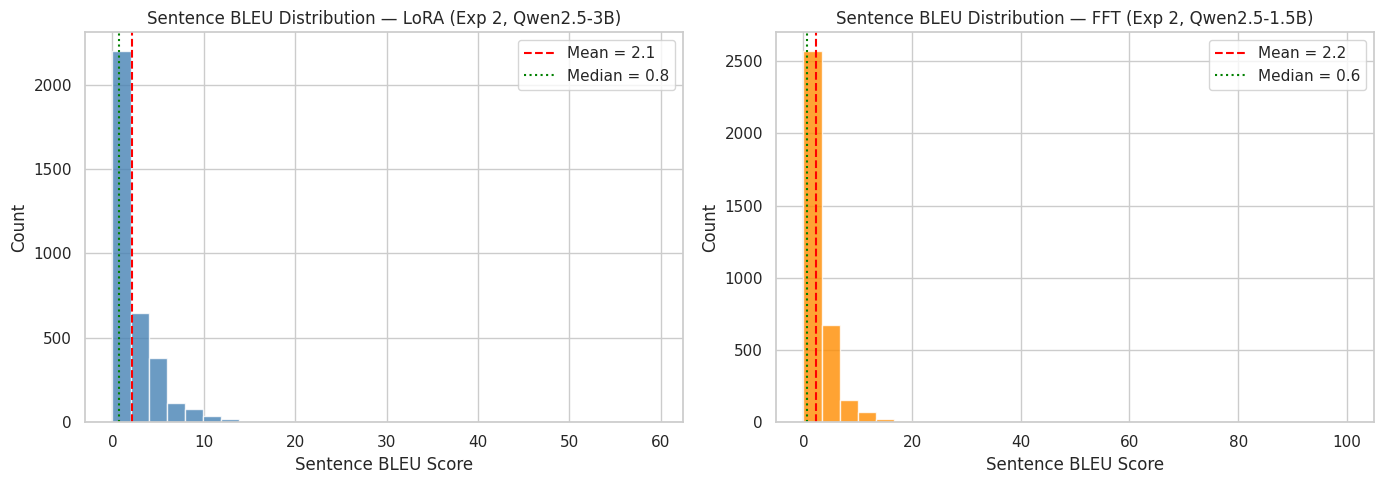

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, label, color in zip(
    axes,
    [sent_bleus_lora, sent_bleus_fft],
    ['LoRA (Exp 2, Qwen2.5-3B)', 'FFT (Exp 2, Qwen2.5-1.5B)'],
    ['steelblue', 'darkorange']
):
    ax.hist(scores, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(scores), color='red', linestyle='--',
               label=f'Mean = {np.mean(scores):.1f}')
    ax.axvline(np.median(scores), color='green', linestyle=':',
               label=f'Median = {np.median(scores):.1f}')
    ax.set_title(f'Sentence BLEU Distribution — {label}')
    ax.set_xlabel('Sentence BLEU Score')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp2_bleu_distributions.png', dpi=150)
plt.show()


## 7. Sample Qualitative Comparisons

In [10]:
with open(TEST_JSONL, encoding='utf-8') as f:
    test_records = [json.loads(line) for line in f if line.strip()]

N = 8
print(f'{"Modern English Source":<45} {"LoRA Output":<45} {"FFT Output":<45} {"Reference":<45}')
print('\u2500' * 185)

for i in range(N):
    msgs = test_records[i]['messages']
    src  = next(m['content'] for m in msgs if m['role'] == 'user')
    ref  = next(m['content'] for m in msgs if m['role'] == 'assistant')

    def trunc(s, n=42):
        return s[:n] + '...' if len(s) > n else s

    print(f'{trunc(src):<45} {trunc(hyps_lora[i]):<45} {trunc(hyps_fft[i]):<45} {trunc(ref):<45}')


Modern English Source                         LoRA Output                                   FFT Output                                    Reference                                    
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Whatever I speak, I'll risk my life to pro... O noble York!                                 What, shall we fight?                           How high a pitch his resolution soars!Th...
Yes, you want to leave so you can join Ric... Why, then, my lord, we will not go with yo... What is your name?                              Most mighty sovereign,You have no cause ...
My lord, from Oxford I've sent the heads o... What! have they been hanged?                  What sayst thou?                                Thy pains, Fitzwater, shall not be forgo...
He will die.                                  O, he is dead!                  